In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#simpeg Imports -- For forward problem
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

mpl.rcParams.update({"font.size": 14}) #(No Idea..)

#Simpeg imports -- Not for forward problem
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

save_output = False  # Optional, (No Idea..)

## Sythetic Data and Model First
#### Topo First

In [21]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-200, 200, 41), np.linspace(-200, 200, 41))
rng = np.random.default_rng(seed=737)
z_topo = (
    15 * np.exp(-(x_topo**2 + y_topo**2) / 80**2)
    + 100.0
    + rng.uniform(low=0.0, high=0.5, size=x_topo.shape)
)

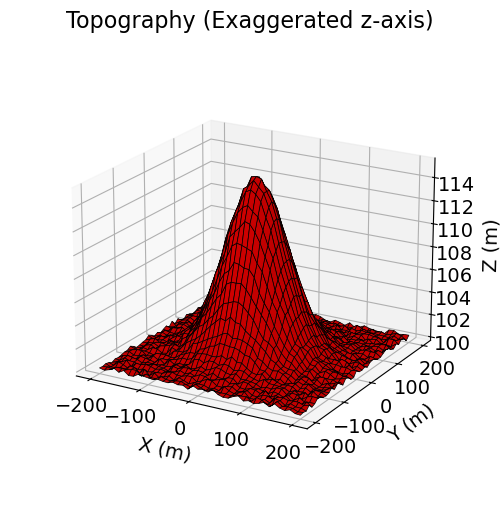

In [22]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
# ax.set_zlim([z_topo.max() - 40, z_topo.max()])
ax.plot_surface(x_topo, y_topo, z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

In [23]:
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo]

#### Define Observation locations

In [24]:
#For a ground survey (like Mt. Milligan), topo and observation locations are the same except spaced out. 
#Sampled every 10 meters, on surface.
x = np.linspace(-80.0, 80.0, 17)
y = np.linspace(-80.0, 80.0, 17)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y])  # Ground Survey
receiver_locations = np.c_[x, y, z]


In [25]:
# Define the component(s) of the field we want to simulate as a list of strings.
# Here we simulation total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations, components=components) #List of receivers from locations
receiver_list = [receiver_list]

# Define the inducing field
inclination = 90  # inclination [deg]
declination = 0  # declination [deg]
amplitude = 50000  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

#### Design Tensor (Mesh)

In [26]:
# The mesh is divifing up our model into many small cells, each with their own susceptibility value.
# Generate tensor mesh with top at z = 0 m
dh = 5.0 #Cell width of 5m
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)] #Added 40m of padding 
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
mesh.origin += np.r_[0.0, 0.0, z_topo.max()]

#### Define Active cells

In [27]:
#By active cells, we mean the cells that are below the topography. Air cells should not have a suceptibility value.
# Indices of the active mesh cells from topography (e.g. cells below surface), boolenans
active_cells = active_from_xyz(mesh, topo_xyz) #simpeg function

#### Mapping Active Cells

In [28]:
# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active) #simpeg identity map

#### Define the Model

In [29]:
# Weakly susceptible background, strognly susceptible sphere (to start)

# Define susceptibility values for each unit in SI
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

# Instantiate a vector array. Models in SimPEG are vector arrays.
model = background_susceptibility * np.ones(n_active)

# You can use SimPEG utilities to add structures to the model more concisely,
# or index the mesh cells manually.
ind_sphere = model_builder.get_indices_sphere(
    np.r_[0.0, 0.0, 55.0], 16.0, mesh.cell_centers
)
ind_sphere = ind_sphere[active_cells]
model[ind_sphere] = sphere_susceptibility

In [30]:
# Mapping to ignore inactive cells when plotting model
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

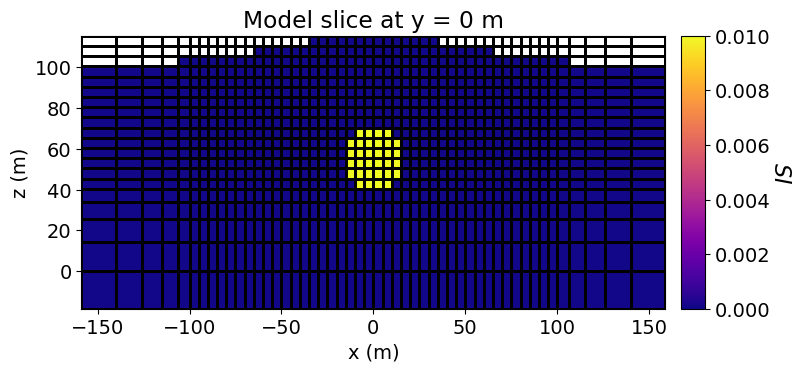

In [31]:
# Plot Susceptibility Model
fig = plt.figure(figsize=(8, 3.5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(model))
mesh.plot_slice(
    plotting_map * model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

#### Define forward simulation

In [32]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

#### Simulate total environemnt data

In [56]:
dobs = simulation.dpred(model) #get predicted data from model

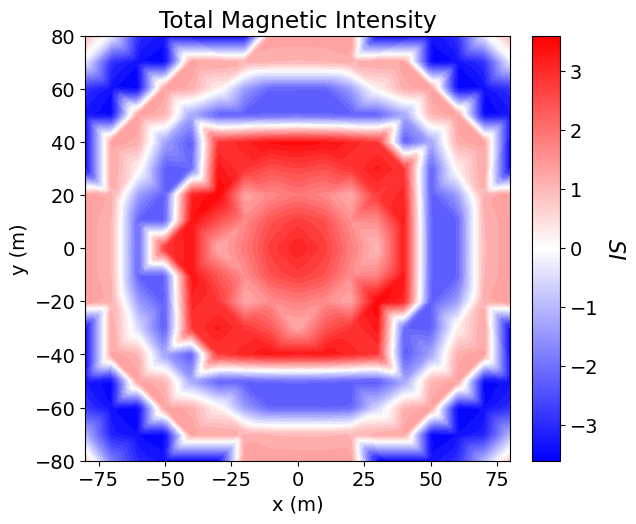

In [57]:
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dobs)), vmax=np.max(np.abs(dobs)))
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Total Magnetic Intensity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$SI$", rotation=270, labelpad=20, size=16)

plt.show()


## Now invert data 

In [ ]:
#We already have:

#The survey --> survey
#The data --> dobs
#The topography --> topo_xyz
#Receiver locations --> receiver_locations
#The mesh --> mesh
#active cells --> active_cells
#Mapping acitve cells --> model_map
#Forward operator --> simulation

#Assign Uncertainties
maximum_anomaly = np.max(np.abs(dpred))
floor_uncertainty = 0.02 * maximum_anomaly
uncertainties = floor_uncertainty * np.ones(np.shape(dpred))
print("Floor uncertainty: {}".format(floor_uncertainty))

#Create data object
data_object = data.Data(survey, dobs=dpred, standard_deviation=uncertainties)

Floor uncertainty: 0.07201924328714238


### Starting and reference models

In [40]:
starting_tensor_model = 1e-6 * np.ones(n_active)
reference_tensor_model = np.zeros_like(starting_tensor_model)

### Define Data Misfit

In [48]:
# Using L2 norm of the weighted residual between the observed and predicted data for a given model
data_misfit = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

### Define the Regularization

In [46]:
#Using weighted least squares regularization to costrain the rgularization result
regularization = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    length_scale_x=1.0,
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_tensor_model,
    reference_model_in_smooth=False,
)

### Define Optimization Algorithm

In [47]:
optimization = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

### Define the inverse problem

In [50]:
# Full inverse problem definition needs daata misfit, regularization, and optimization objects
inverse_problem_L2 = inverse_problem.BaseInvProblem(data_misfit, regularization, optimization)

## Provide Inversion Directives

In [52]:
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

## Define and Run Inversion

In [53]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inverse_problem_L2, directives_list)

# Run inversion
recovered_tensor_model = inv_L2.run(starting_tensor_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 289.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.91e+09  3.02e+05  7.83e-08  3.02e+05                         0           inf          inf                
   1  1.91e+09  2.44e+05  1.11e-05  2.65e+05    2.19e+08      0      10       7.37e-01     1.84e+08              
   2  9.55e+08  1.05e+05  6.92e-05  1.71e+05    2.06e+08      0      7        5.56e-03     1.20e+06              
   3  4.78e+08  5.34e+04  1.42e-04  1.21e+05    5.88e+07      0      6        6.41e-03     3.74e+05              
   4  2.39e+08  2.21e+04  2.22e-04  7.53e+04    4.17e+07      0      7        7.89e-03     3.30e+05              
   5  1.19e+08  8.18e+03  3.02e-04  4.42e+04    2.58e+07      0      8        6.66e-03 

## Plot Data Misfit

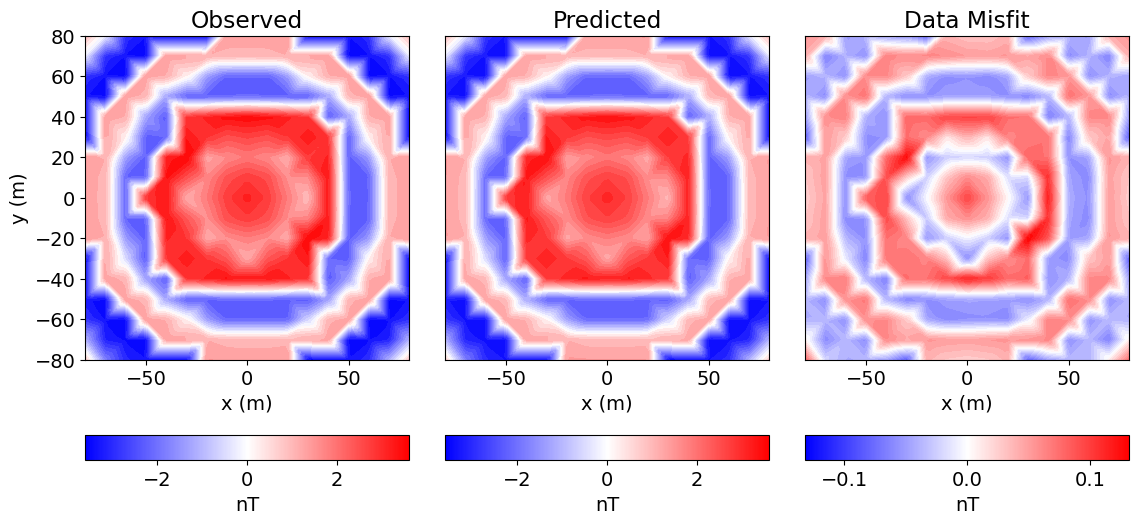

In [58]:
# Predicted data with final recovered model.
dpred_inverse = inverse_problem_L2.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_inverse, (dobs - dpred_inverse)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_inverse))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()